In [1]:
import json, hashlib, cv2
import numpy as np
from pathlib import Path
from deepface import DeepFace

26-10-03 03:41:54 - ⚠️ 
 ⚠️ DEPRECATION WARNING:
 Running 'pip install deepface' alone will no longer be sufficient and will
 NOT install a default backend in an upcoming major release.

 Currently, TensorFlow is included by default, but this behavior will be deprecated.
 Please explicitly specify your preferred backend engine when installing:

   -> pip install deepface[tensorflow]
   -> pip install deepface[pytorch]

 Otherwise, you will encounter 'module not found' errors.



I0000 00:00:1790979114.892190  175733 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790979114.892670  175733 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790979116.013976  175733 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790979116.014268  175733 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
DATABASE_DIR = Path("../datasets/raw_data/")
CROPS_DIR = Path("../datasets/dataset_deepface/")
MANIFEST = Path("../datasets/results/crops_manifest_deepface.json")
STATE = Path("../datasets/results/crops_state_deepface.json")   # resume info

DETECTOR = "yunet"          # or "retinaface" for better quality
EXTS = (".jpg", ".jpeg", ".png")
MIN_FACE_PX, MIN_CONF = 40, 0.90
EXPAND = 10                 # expand_percentage, keep the same for the query image

In [3]:
CROPS_DIR.mkdir(parents=True, exist_ok=True)
MANIFEST.parent.mkdir(parents=True, exist_ok=True)

#### **Step A: Create the crop dataset (one time)**

In [4]:
manifest = json.loads(MANIFEST.read_text()) if MANIFEST.exists() else {}
state = json.loads(STATE.read_text()) if STATE.exists() else {}
hashes = state.setdefault("hashes", {})            # md5 -> first copy's source_rel
exact_dupes = state.setdefault("exact_dupes", {})  # skipped file -> first copy
no_face = set(state.setdefault("no_face", []))     # photos with no valid face

def save():
    MANIFEST.write_text(json.dumps(manifest))
    state["no_face"] = sorted(no_face)
    STATE.write_text(json.dumps(state))

def file_hash(p):
    h = hashlib.md5()
    with open(p, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

all_paths = sorted(p for p in DATABASE_DIR.rglob("*") if p.suffix.lower() in EXTS)
processed = {m["source_rel"] for m in manifest.values()} | set(exact_dupes) | no_face
todo = [p for p in all_paths if p.relative_to(DATABASE_DIR).as_posix() not in processed]
print(f"{len(all_paths)} images, {len(todo)} to process")

for n, path in enumerate(todo, 1):
    if n % 25 == 0:
        save()
        print(f"{n}/{len(todo)}")

    rel = path.relative_to(DATABASE_DIR)
    rel_s = rel.as_posix()

    # Layer 1: skip byte-identical files before the slow detection
    h = file_hash(path)
    first = hashes.get(h)
    if first is not None and first != rel_s:
        exact_dupes[rel_s] = first
        continue
    hashes[h] = rel_s

    try:
        faces = DeepFace.extract_faces(
            str(path), detector_backend=DETECTOR, align=True,
            enforce_detection=True, expand_percentage=EXPAND)
    except Exception:
        faces = []

    kept = 0
    for f in faces:
        fa, conf = f["facial_area"], f.get("confidence", 1.0)
        if fa["w"] < MIN_FACE_PX or fa["h"] < MIN_FACE_PX or conf < MIN_CONF:
            continue
        stem = rel.stem if kept == 0 else f"{rel.stem}__{kept}"
        out_rel = rel.with_name(stem + ".jpg")          # same subfolders, same name
        out_path = CROPS_DIR / out_rel
        out_path.parent.mkdir(parents=True, exist_ok=True)

        img = (f["face"] * 255).clip(0, 255).astype(np.uint8)
        cv2.imwrite(str(out_path), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

        manifest[out_rel.as_posix()] = {
            "source_rel": rel_s,
            "box": [fa["x"], fa["y"], fa["w"], fa["h"]],
            "conf": float(conf),
            "detector": DETECTOR,
        }
        kept += 1

    if kept == 0:
        no_face.add(rel_s)

save()
print(f"{len(manifest)} face crops saved in {CROPS_DIR.resolve()}")
print(f"{len(exact_dupes)} exact duplicate files skipped, {len(no_face)} photos without a valid face")

513 images, 0 to process
298 face crops saved in /home/rakesh/GitRepo/Object-Detection-Models/datasets/dataset_deepface
0 exact duplicate files skipped, 215 photos without a valid face


#### **C1: Embed every crop (cached and resumable)**

In [12]:
import json, pickle
import numpy as np
from pathlib import Path
from deepface import DeepFace

MODEL = "Facenet512"
CROPS_DIR = Path("../datasets/dataset_deepface/")
MANIFEST = Path("../datasets/results/crops_manifest_deepface.json")
EMB_PATH = Path(f"../datasets/results/emb_all_{MODEL}_deepface.pkl")    # every crop, before dedup
INDEX_PATH = Path(f"../datasets/results/index_{MODEL}_deepface.pkl")    # final, deduplicated

manifest = json.loads(MANIFEST.read_text())
emb = pickle.load(open(EMB_PATH, "rb")) if EMB_PATH.exists() else {}

todo = [n for n in manifest if n not in emb and (CROPS_DIR / n).exists()]
print(f"{len(manifest)} crops in manifest, {len(todo)} to embed")

failed = []
for k, name in enumerate(todo, 1):
    try:
        rep = DeepFace.represent(str(CROPS_DIR / name), model_name=MODEL,
                                 detector_backend="skip", enforce_detection=False)[0]
        emb[name] = rep["embedding"]
    except Exception as e:
        failed.append(name)
        print("failed:", name, e)
    if k % 50 == 0:
        pickle.dump(emb, open(EMB_PATH, "wb"))
        print(f"{k}/{len(todo)}")

pickle.dump(emb, open(EMB_PATH, "wb"))
print(len(emb), "embedded,", len(failed), "failed")

298 crops in manifest, 298 to embed
50/298
100/298
150/298
200/298
250/298
298 embedded, 0 failed


#### **C2: Remove duplicates and build the index**

In [13]:
DUP_THRESHOLD = 0.05      # cosine distance below this = same picture
SCOPE = "folder"          # "folder": dedupe within the same folder, "global": across all folders

def unit(v):
    v = np.asarray(v, dtype=np.float32)
    return v / np.linalg.norm(v)

index, groups = {}, {}    # groups: key -> (kept names, kept unit vectors)

for name in sorted(emb):
    if name not in manifest or not (CROPS_DIR / name).exists():
        continue                                  # rejected or deleted in Step B
    v = unit(emb[name])
    g = Path(name).parent.as_posix() if SCOPE == "folder" else ""
    kept_names, kept_vecs = groups.setdefault(g, ([], []))

    if kept_vecs:
        d = 1 - np.array(kept_vecs) @ v
        j = int(np.argmin(d))
        if d[j] < DUP_THRESHOLD:
            index[kept_names[j]]["dupes"].append(
                {"crop": name, "source_rel": manifest[name]["source_rel"], "dist": float(d[j])})
            continue

    index[name] = {"emb": emb[name], "dupes": [], **manifest[name]}
    kept_names.append(name)
    kept_vecs.append(v)

n_dupes = sum(len(e["dupes"]) for e in index.values())
print(f"{len(index)} kept, {n_dupes} duplicates skipped")
pickle.dump(index, open(INDEX_PATH, "wb"))
print("saved ->", INDEX_PATH.resolve())

177 kept, 121 duplicates skipped
saved -> /home/rakesh/GitRepo/Object-Detection-Models/datasets/results/index_Facenet512_deepface.pkl


#### **C3: Check what was removed**

In [14]:
pairs = [(e["dupes"][k]["dist"], name, e["dupes"][k]["crop"])
         for name, e in index.items() for k in range(len(e["dupes"]))]
pairs.sort(reverse=True)                       # least certain duplicates first
for d, kept, dup in pairs[:10]:
    print(f"{d:.3f}  kept={kept}  skipped={dup}")

0.050  kept=9. Shyaam Kumar Suman/img0014.jpg  skipped=9. Shyaam Kumar Suman/img0015.jpg
0.050  kept=8. Shaksham Kumar Suman/img0150.jpg  skipped=8. Shaksham Kumar Suman/img0151.jpg
0.050  kept=8. Shaksham Kumar Suman/img0045.jpg  skipped=8. Shaksham Kumar Suman/img0046.jpg
0.050  kept=9. Shyaam Kumar Suman/img0068.jpg  skipped=9. Shyaam Kumar Suman/img0070.jpg
0.050  kept=8. Shaksham Kumar Suman/img0144.jpg  skipped=8. Shaksham Kumar Suman/img0149.jpg
0.049  kept=8. Shaksham Kumar Suman/img0266.jpg  skipped=8. Shaksham Kumar Suman/img0283.jpg
0.049  kept=8. Shaksham Kumar Suman/img0209.jpg  skipped=8. Shaksham Kumar Suman/img0224.jpg
0.049  kept=2. Rakesh Ranjan/img0021.jpg  skipped=2. Rakesh Ranjan/img0030.jpg
0.049  kept=8. Shaksham Kumar Suman/img0130.jpg  skipped=8. Shaksham Kumar Suman/img0131.jpg
0.049  kept=8. Shaksham Kumar Suman/img0199.jpg  skipped=8. Shaksham Kumar Suman/img0201.jpg


#### **Sanity check on the whole index**

In [17]:
V = np.array([unit(e["emb"]) for e in index.values()])
D = 1 - V @ V.T
iu = np.triu_indices(len(V), k=1)
vals = D[iu]
print("closest remaining pair:", vals.min().round(3))
print("pairs below 0.10:", int((vals < 0.10).sum()))

closest remaining pair: 0.051
pairs below 0.10: 257


#### **Check 1: distribution of removed distances**

In [16]:
d_all = np.array([dp["dist"] for e in index.values() for dp in e["dupes"]])
print("removed distances  min/50%/90%/max:", np.percentile(d_all, [0, 50, 90, 100]).round(4))

removed distances  min/50%/90%/max: [0.0074 0.0349 0.048  0.05  ]


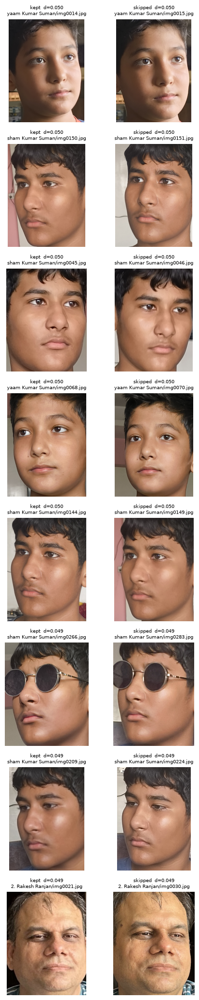

In [18]:
# Check 2: view the least certain duplicates side by side
import math, cv2
import matplotlib.pyplot as plt

pairs = [(dp["dist"], kept, dp["crop"])
         for kept, e in index.items() for dp in e["dupes"]]
pairs.sort(reverse=True)           # highest distance = least certain

top = pairs[:8]
fig, axes = plt.subplots(len(top), 2, figsize=(5, 2.6 * len(top)))
for row, (d, kept, dup) in zip(axes, top):
    for ax, name, tag in [(row[0], kept, "kept"), (row[1], dup, "skipped")]:
        ax.imshow(cv2.cvtColor(cv2.imread(str(CROPS_DIR / name)), cv2.COLOR_BGR2RGB))
        ax.set_title(f"{tag}  d={d:.3f}\n{name[-28:]}", fontsize=7)
        ax.axis("off")
plt.tight_layout()
plt.show()

In [19]:
# Check 3: which folders lost the most
from collections import Counter
lost = Counter(Path(n).parent.as_posix() for e in index.values()
               for n in [dp["crop"] for dp in e["dupes"]])
print(lost.most_common(10))

[('8. Shaksham Kumar Suman', 67), ('2. Rakesh Ranjan', 22), ('9. Shyaam Kumar Suman', 22), ('4. Sunny Singh', 7), ('10. Nidhi', 1), ('5. Tejrit Tyagi', 1), ('6. Shrinav Tyagi', 1)]


## **Step D: Search with a raw query image**

In [21]:
import pickle
import numpy as np
import cv2
from pathlib import Path
from deepface import DeepFace

# ---------- Config ----------
DATABASE_DIR = Path("../datasets/raw_data/")
QUERY_IMAGE = "../datasets/images/Tejrit.jpg"

MODEL = "Facenet512"
INDEX_PATH = Path(f"../datasets/results/index_{MODEL}_deepface.pkl")

QUERY_DETECTOR = "retinaface"   # strongest detector, since this one face drives the search
EXPAND = 10                     # must match EXPAND in Step A
QUERY_FACE_IDX = None           # None = largest face; or 0, 1, ... to force one

STRICT_THRESHOLD = 0.30         # Facenet512 cosine; ArcFace would be ~0.68
TOP_K = 12
MIN_DIST = 0.0                  # set to 0.05 to hide the query photo itself if it is in the database
CONF_K = 15                     # steepness of the confidence curve (ArcFace: ~7)

# ---------- Helpers ----------
def unit(v):
    v = np.asarray(v, dtype=np.float32)
    return v / np.linalg.norm(v, axis=-1, keepdims=True)

def confidence_pct(d, threshold=STRICT_THRESHOLD, k=CONF_K):
    """Heuristic score: 50% at the threshold, ~100% near 0, ~0% far above."""
    return float(100 / (1 + np.exp(k * (d - threshold))))

# ---------- Load index ----------
with open(INDEX_PATH, "rb") as f:
    index = pickle.load(f)

names = list(index.keys())
vecs = unit(np.array([index[n]["emb"] for n in names]))
print(f"{len(names)} face crops in index")

# ---------- Detect and crop the face in the raw query image ----------
q_faces = DeepFace.extract_faces(QUERY_IMAGE, detector_backend=QUERY_DETECTOR,
                                 align=True, enforce_detection=True,
                                 expand_percentage=EXPAND)
print(f"{len(q_faces)} face(s) found in query image")

if QUERY_FACE_IDX is None:
    q_face = max(q_faces, key=lambda f: f["facial_area"]["w"] * f["facial_area"]["h"])
else:
    q_face = q_faces[QUERY_FACE_IDX]

qa = q_face["facial_area"]
q_box = (qa["x"], qa["y"], qa["w"], qa["h"])

# ---------- Embed the query crop the same way the database crops were ----------
crop = (q_face["face"] * 255).clip(0, 255).astype(np.uint8)
crop_bgr = cv2.cvtColor(crop, cv2.COLOR_RGB2BGR)
crop_bgr = cv2.imdecode(cv2.imencode(".jpg", crop_bgr)[1], cv2.IMREAD_COLOR)  # match saved JPEG crops

q = unit(DeepFace.represent(crop_bgr, model_name=MODEL,
                            detector_backend="skip",
                            enforce_detection=False)[0]["embedding"])

# ---------- Rank by cosine distance, best crop per source photo ----------
dist = 1 - vecs @ q
order = np.argsort(dist)

seen, matches = set(), []
for i in order:
    d = float(dist[i])
    if d < MIN_DIST:
        continue
    meta = index[names[i]]
    if meta["source_rel"] in seen:
        continue
    seen.add(meta["source_rel"])
    matches.append({
        "crop": names[i],
        "dist": d,
        "conf": confidence_pct(d),
        "src_path": DATABASE_DIR / meta["source_rel"],
        "box": tuple(meta["box"]),
        "n_dupes": len(meta["dupes"]),
    })
    if len(matches) >= TOP_K:
        break

# ---------- Report ----------
n_strict = sum(m["dist"] < STRICT_THRESHOLD for m in matches)
print(f"\n{n_strict} strict matches (< {STRICT_THRESHOLD}); showing top {len(matches)}\n")
for i, m in enumerate(matches, 1):
    print(f"#{i:<2} d={m['dist']:.3f}  conf={m['conf']:5.1f}%  dupes={m['n_dupes']}  {m['crop']}")

177 face crops in index
1 face(s) found in query image

11 strict matches (< 0.3); showing top 12

#1  d=0.036  conf= 98.1%  dupes=0  5. Tejrit Tyagi/img0001.jpg
#2  d=0.170  conf= 87.6%  dupes=0  5. Tejrit Tyagi/img0015.jpg
#3  d=0.182  conf= 85.4%  dupes=0  5. Tejrit Tyagi/img0005.jpg
#4  d=0.216  conf= 78.0%  dupes=0  5. Tejrit Tyagi/img0014.jpg
#5  d=0.232  conf= 73.5%  dupes=0  5. Tejrit Tyagi/img0017.jpg
#6  d=0.236  conf= 72.3%  dupes=0  5. Tejrit Tyagi/img0013.jpg
#7  d=0.239  conf= 71.5%  dupes=0  5. Tejrit Tyagi/img0012.jpg
#8  d=0.240  conf= 71.0%  dupes=0  5. Tejrit Tyagi/img0018.jpg
#9  d=0.285  conf= 55.6%  dupes=0  5. Tejrit Tyagi/img0009.jpg
#10 d=0.285  conf= 55.6%  dupes=1  5. Tejrit Tyagi/img0006.jpg
#11 d=0.287  conf= 54.8%  dupes=0  5. Tejrit Tyagi/img0016.jpg
#12 d=0.304  conf= 48.6%  dupes=0  5. Tejrit Tyagi/img0008.jpg


## **Step 5: Plot with face boxes**

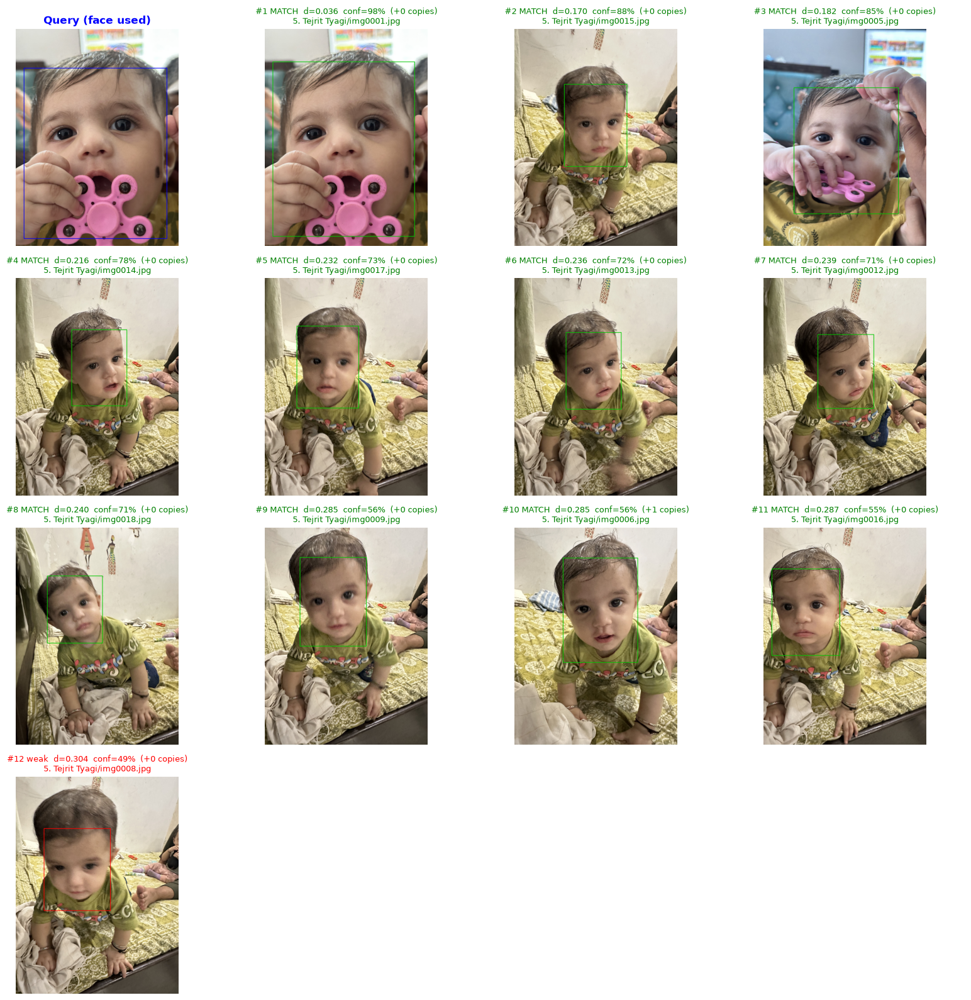

In [22]:
import math
import matplotlib.pyplot as plt

def load_with_box(path, box, color):
    img = cv2.imread(str(path))
    if img is None:
        raise FileNotFoundError(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    x, y, w, h = box
    t = max(2, img.shape[1] // 300)
    cv2.rectangle(img, (x, y), (x + w, y + h), color, t)
    return img

cols = 4
rows = math.ceil((1 + len(matches)) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()

axes[0].imshow(load_with_box(QUERY_IMAGE, q_box, (0, 0, 255)))
axes[0].set_title("Query (face used)", color="blue", fontweight="bold")

for i, m in enumerate(matches, 1):
    good = m["dist"] < STRICT_THRESHOLD
    folder = Path(m["crop"]).parent.as_posix()
    axes[i].imshow(load_with_box(m["src_path"], m["box"],
                                 (0, 200, 0) if good else (255, 0, 0)))
    axes[i].set_title(
        f"#{i} {'MATCH' if good else 'weak'}  d={m['dist']:.3f}  conf={m['conf']:.0f}%"
        f"  (+{m['n_dupes']} copies)\n{folder}/{m['src_path'].name[:18]}",
        fontsize=9, color="green" if good else "red")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

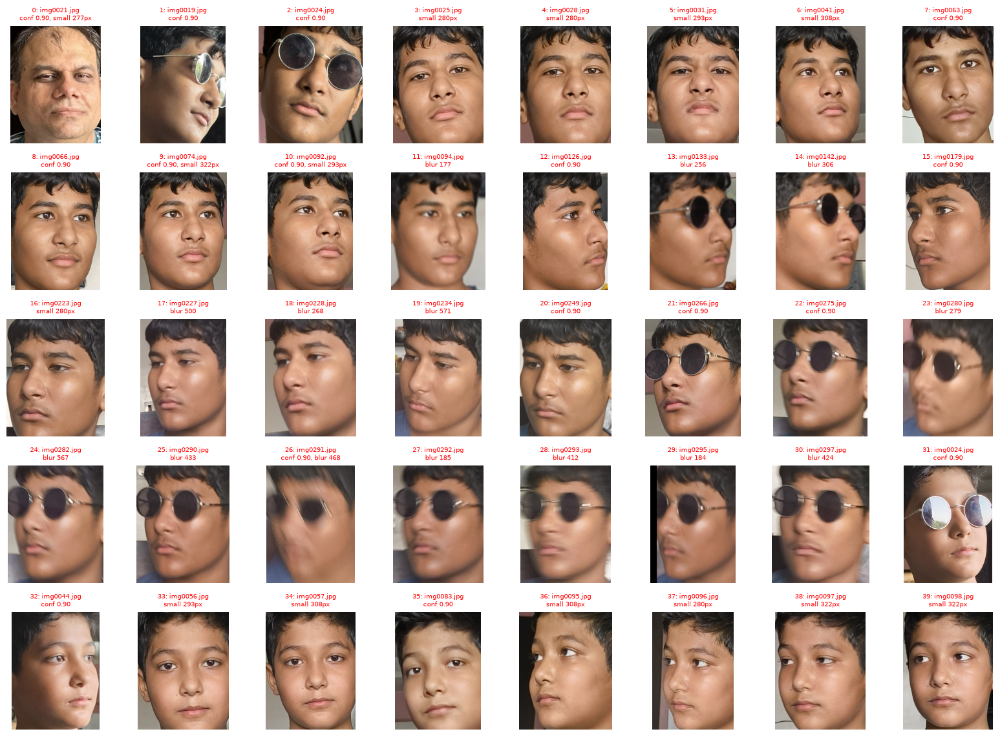

page 1/2


In [9]:
def show(names, page=0, per_page=40, cols=8):
    chunk = names[page * per_page:(page + 1) * per_page]
    rows = math.ceil(len(chunk) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2.3 * rows))
    axes = np.atleast_1d(axes).flatten()
    for ax in axes:
        ax.axis("off")
    for ax, name in zip(axes, chunk):
        img = cv2.cvtColor(cv2.imread(str(CROPS_DIR / name)), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(f"{names.index(name)}: {Path(name).name[:14]}\n{', '.join(flags.get(name, []))[:26]}",
                     fontsize=7, color="red" if name in flags else "black")
    plt.tight_layout()
    plt.show()
    print(f"page {page + 1}/{math.ceil(len(names) / 40)}")

flagged = sorted(flags)
show(flagged, page=0)      # change page=1, 2, ... to continue

In [5]:
import json, shutil, math
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

CROPS_DIR = Path("../datasets/dataset_deepface/")
REJECT_DIR = Path("../datasets/dataset_deepface_rejected/")
MANIFEST = Path("../datasets/results/crops_manifest_deepface.json")
STATE = Path("../datasets/results/crops_state_deepface.json")

manifest = json.loads(MANIFEST.read_text())
state = json.loads(STATE.read_text())
rejected = set(state.setdefault("rejected", []))
no_face = set(state.setdefault("no_face", []))

def save():
    MANIFEST.write_text(json.dumps(manifest))
    state["rejected"] = sorted(rejected)
    state["no_face"] = sorted(no_face)
    STATE.write_text(json.dumps(state))

def drop(name):
    """Forget a crop. If its source photo has no other crop left, mark the
    photo as handled so Step A doesn't re-crop it on a rerun."""
    meta = manifest.pop(name, None)
    rejected.add(name)
    if meta and not any(m["source_rel"] == meta["source_rel"] for m in manifest.values()):
        no_face.add(meta["source_rel"])

def reject(names):
    """Move crops to the rejected folder (keeps the folder structure)."""
    for name in names:
        src = CROPS_DIR / name
        if src.exists():
            dst = REJECT_DIR / name
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.move(str(src), str(dst))
        drop(name)
    save()
    print(f"rejected {len(names)}, {len(manifest)} crops remain")

# Sync: crops you deleted by hand in the file explorer
gone = [n for n in manifest if not (CROPS_DIR / n).exists()]
for n in gone:
    drop(n)
save()

# Files on disk that are not in the manifest
on_disk = {p.relative_to(CROPS_DIR).as_posix() for p in CROPS_DIR.rglob("*.jpg")}
orphans = sorted(on_disk - set(manifest))
print(f"{len(manifest)} crops, {len(gone)} removed by hand, {len(orphans)} orphan files")

298 crops, 0 removed by hand, 0 orphan files


In [6]:
BLUR_MIN = 40        # Laplacian variance on a 112 px crop; lower = blurrier
CONF_MIN = 0.95
SMALL_PX = 60        # source face smaller than this is a weak embedding

def blur_score(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (112, 112))
    return cv2.Laplacian(img, cv2.CV_64F).var()

flags = {}   # name -> list of reasons
for name, m in manifest.items():
    why = []
    if m["conf"] < CONF_MIN:
        why.append(f"conf {m['conf']:.2f}")
    if min(m["box"][2], m["box"][3]) < SMALL_PX:
        why.append(f"small {m['box'][2]}x{m['box'][3]}")
    if "__" in Path(name).stem:
        why.append("extra face")            # 2nd/3rd face in a photo, often a bystander
    b = blur_score(CROPS_DIR / name)
    if b < BLUR_MIN:
        why.append(f"blur {b:.0f}")
    if why:
        flags[name] = why

print(f"{len(flags)} of {len(manifest)} crops flagged")

292 of 298 crops flagged


In [7]:
from collections import Counter

reasons = Counter()
for why in flags.values():
    for w in why:
        reasons[w.split()[0]] += 1
print(reasons)

confs = np.array([m["conf"] for m in manifest.values()])
sizes = np.array([min(m["box"][2], m["box"][3]) for m in manifest.values()])
blurs = np.array([blur_score(CROPS_DIR / n) for n in manifest])

for label, arr in [("conf", confs), ("face px", sizes), ("blur", blurs)]:
    print(label, "min/10%/median/90%:", np.percentile(arr, [0, 10, 50, 90]).round(2))

Counter({'conf': 292})
conf min/10%/median/90%: [0.9  0.91 0.92 0.94]
face px min/10%/median/90%: [ 277.   405.   785.  1376.9]
blur min/10%/median/90%: [ 177.37  736.89 1567.73 3077.75]


43 of 298 crops flagged


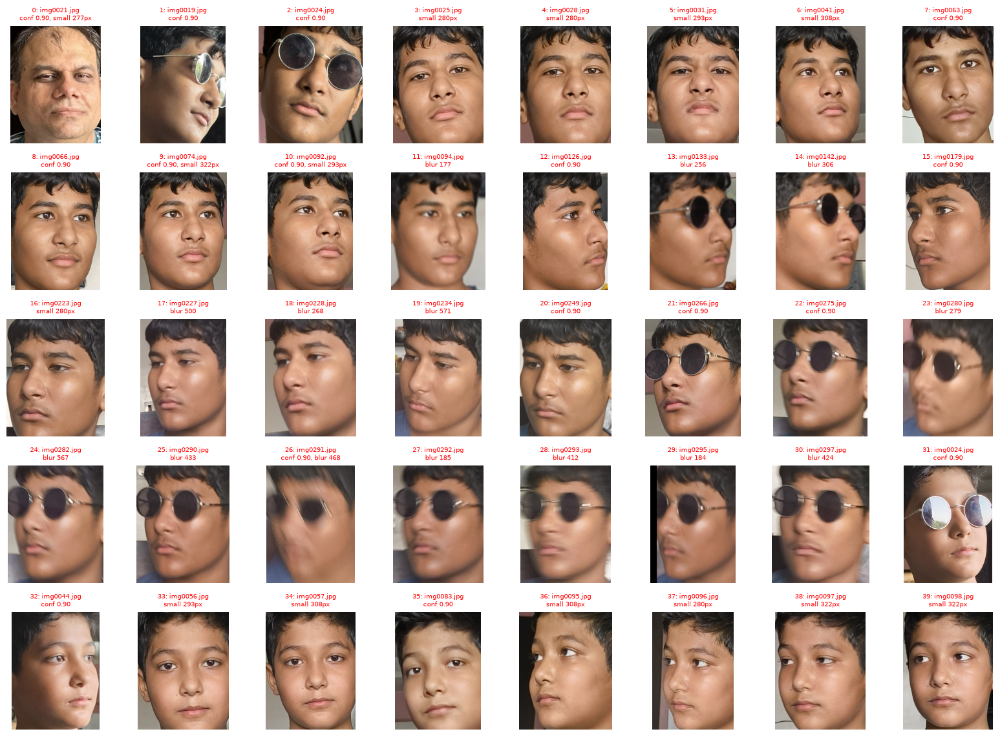

page 1/2


In [10]:
PCT = 5   # flag the worst 5% per measure

names_all = list(manifest)
conf_cut = np.percentile(confs, PCT)
blur_cut = np.percentile(blurs, PCT)
size_cut = np.percentile(sizes, PCT)

flags = {}
for name, c, s, b in zip(names_all, confs, sizes, blurs):
    why = []
    if c <= conf_cut: why.append(f"conf {c:.2f}")
    if s <= size_cut: why.append(f"small {s}px")
    if b <= blur_cut: why.append(f"blur {b:.0f}")
    if "__" in Path(name).stem: why.append("extra face")
    if why:
        flags[name] = why

print(f"{len(flags)} of {len(manifest)} crops flagged")
flagged = sorted(flags)
show(flagged, page=0)

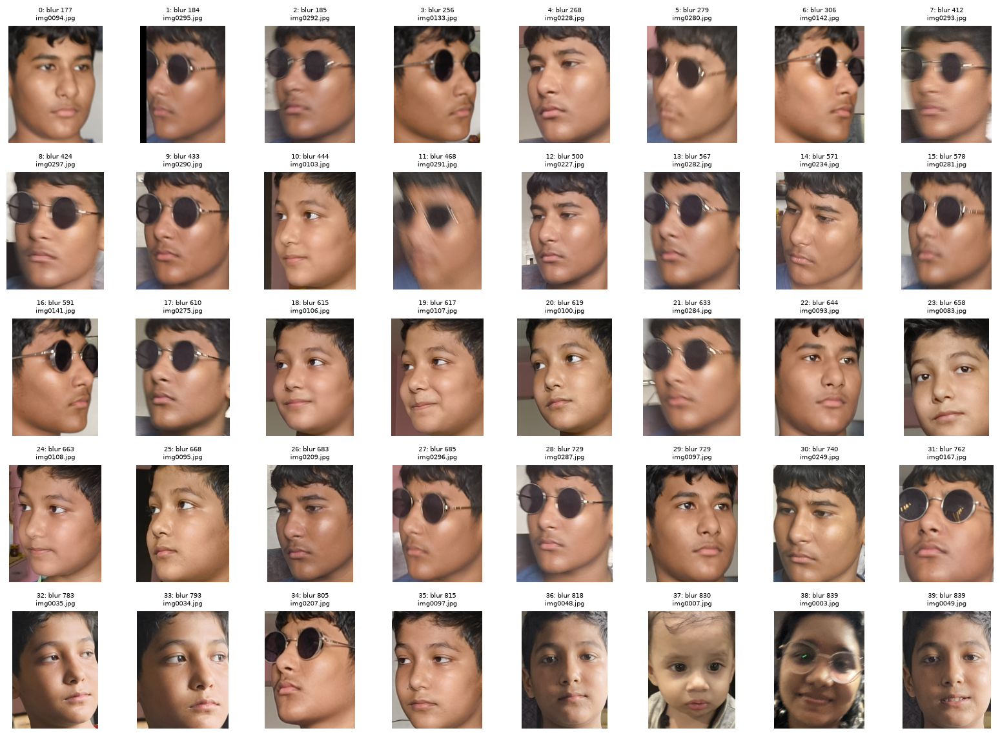

In [11]:
names_all = list(manifest)
order = np.argsort(blurs)                     # blurriest first
blurry_sorted = [names_all[i] for i in order]
blur_of = {names_all[i]: blurs[i] for i in range(len(names_all))}

def show_blur(names, start=0, n=40, cols=8):
    chunk = names[start:start + n]
    rows = math.ceil(len(chunk) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2.3 * rows))
    axes = np.atleast_1d(axes).flatten()
    for ax in axes:
        ax.axis("off")
    for k, (ax, name) in enumerate(zip(axes, chunk)):
        img = cv2.cvtColor(cv2.imread(str(CROPS_DIR / name)), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(f"{start + k}: blur {blur_of[name]:.0f}\n{Path(name).name[:14]}", fontsize=7)
    plt.tight_layout()
    plt.show()

show_blur(blurry_sorted, start=0)    # then start=40 if needed